# 3주차 코드 과제: 순전파·역전파와 Optimizer

이번 과제에서는 NumPy로 구성된 MLP의 핵심 연산을 직접 완성하고,  
SGD·Momentum·AdaGrad의 학습 곡선을 비교합니다.

## 진행 순서

1. `#채워주세요`로 표시된 부분을 모두 완성합니다.
2. **런타임 → 모두 실행**으로 위에서부터 오류 없이 실행되는지 확인합니다.
3. 세 optimizer의 train loss 그래프를 비교하고 마지막 질문에 답합니다.
4. 실행 결과가 남아 있는 노트북을 제출합니다.

## 제출 안내

- 권장 환경: Google Colab 또는 Jupyter Notebook
- 제출 파일명: `3주차 과제2_기수_이름.ipynb`
- 첫 번째 과제인 Sigmoid 계산 그래프는 안내된 형식의 스크린샷으로 별도 제출합니다.


In [27]:
%pip install numpy


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [28]:
import numpy as np #행렬계산

SEED = 42 #난수가 동일하게 나오도록
np.random.seed(SEED)


#Define network

순전파와 역전파가 어떻게 구현되는지 확인해보세요!

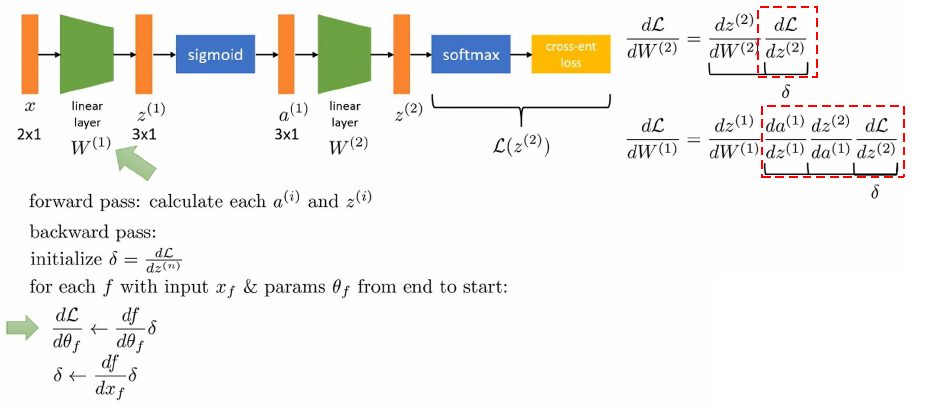

In [29]:
from collections import OrderedDict

class TwoLayerNet: #2층 신경망 

    def __init__(self, input_size, hidden_size, output_size, weight_init_std = 0.01):
        self.params = {}
        self.params['W1'] = weight_init_std * np.random.randn(input_size, hidden_size) #가중치
        self.params['b1'] = np.zeros(hidden_size) #bias, 뉴런개수 설정
        self.params['W2'] = weight_init_std * np.random.randn(hidden_size, output_size)
        self.params['b2'] = np.zeros(output_size)

        self.layers = OrderedDict() #레이어 순서대로 작동
        self.layers['Affine1'] = Affine(self.params['W1'], self.params['b1'])
        self.layers['Relu1'] = Relu()
        self.layers['Affine2'] = Affine(self.params['W2'], self.params['b2'])

        self.lastLayer = SoftmaxWithLoss() #예측 확률, loss 계산


    def predict(self, x):
        for layer in self.layers.values():
            x = layer.forward(x)

        return x #각 클래스에 대한 점수

    # forward
    def loss(self, x, t):
        y = self.predict(x)
        return self.lastLayer.forward(y, t) #손실 계산


    def accuracy(self, x, t):
        y = self.predict(x)
        y = np.argmax(y, axis=1) #출력 점수가 가장 큰 클래스 선택
        if t.ndim != 1 : t = np.argmax(t, axis=1)

        accuracy = np.sum(y == t) / float(x.shape[0])
        return accuracy 

    def gradient(self, x, t): 
        self.loss(x, t) #순전파 실행하며 필요한 값 저장

        # backward
        dout = 1 #최종 loss부터 시작
        dout = self.lastLayer.backward(dout)

        layers = list(self.layers.values())
        layers.reverse() #다음으로 미분 전달
        for layer in layers:
            dout = layer.backward(dout)

        grads = {}
        grads['W1'], grads['b1'] = self.layers['Affine1'].dW, self.layers['Affine1'].db
        grads['W2'], grads['b2'] = self.layers['Affine2'].dW, self.layers['Affine2'].db

        return grads

#Layers

각 레이어에는 init, forward, backward 함수가 정의되어 있습니다.

In [30]:
class Affine:
    def __init__(self, W, b):
        self.W = W
        self.b = b

        self.x = None
        self.original_x_shape = None
        self.dW = None
        self.db = None

    def forward(self, x):
        self.original_x_shape = x.shape
        x = x.reshape(x.shape[0], -1)
        self.x = x

        out = np.dot(x, self.W) + self.b

        return out

    def backward(self, dout):
        dx = np.dot(dout, self.W.T)

        # 계산 그래프를 직접 그려보세요(권장)
        self.dW = np.dot(self.x.T, dout)
        self.db = np.sum(dout, axis=0)

        dx = dx.reshape(*self.original_x_shape)
        return dx

In [31]:
class Relu:
    def __init__(self):
        self.mask = None

    def forward(self, x):
        self.mask = (x <= 0)
        out = x.copy()
        out[self.mask] = 0 #0 이하는 0이 됨

        return out

    def backward(self, dout):
        dout[self.mask] = 0
        dx = dout

        return dx

In [32]:
class SoftmaxWithLoss:
    def __init__(self):
        self.loss = None
        self.y = None
        self.t = None

    def forward(self, x, t):
        self.t = t
        self.y = softmax(x)
        self.loss = cross_entropy_error(self.y, self.t)

        return self.loss

    def backward(self, dout=1):
        batch_size = self.t.shape[0]
        if self.t.size == self.y.size:
            dx = (self.y -self.t) / batch_size
        else:
            dx = self.y.copy()
            dx[np.arange(batch_size), self.t] -= 1
            dx = dx / batch_size

        return dx

#Functions

복습차원에서 빈칸을 채워봅시다!

In [33]:
def softmax(x):
    '''
    x: n x num_class
    '''
    # 계산 안정성 추가
    x = x - np.max(x, axis=-1, keepdims=True)
    return np.exp(x) / np.sum(np.exp(x), axis=1, keepdims=True)

In [34]:
def cross_entropy_error(y, t):
    if y.ndim == 1:
        t = t.reshape(1, t.size)
        y = y.reshape(1, y.size)

    if t.size == y.size:
        t = t.argmax(axis=1)

    batch_size = y.shape[0]
    return -np.sum(np.log(y[np.arange(batch_size), t] + 1e-7)) / batch_size

#Optimizers

파라미터와 기울기를 인수로 받아서 파라미터를 갱신합니다.

SGD는 파라미터를 업데이트할 때, 각 반복마다 계산된 **기울기(gradient)**를 이용하여 파라미터를 업데이트합니다.

$$
\theta_{t+1} = \theta_t - \eta \nabla_\theta J(\theta_t)
$$

- $\theta_t$ : 파라미터  
- $\eta$ : 학습률(learning rate)  
- $\nabla_\theta J(\theta_t)$ : 파라미터에 대한 손실 함수의 기울기(gradient)  

In [35]:
class SGD:

    def __init__(self, lr=0.01):
        self.lr = lr

    def update(self, params, grads):
        for key in params.keys():
            params[key] -= self.lr * grads[key]

Momentum은 이전 기울기를 반영하여 학습을 가속화하는 방법입니다.

$$
v_{t+1} = \alpha v_t - \eta \nabla_\theta J(\theta_t)
$$
$$
\theta_{t+1} = \theta_t + v_{t+1}
$$

- $ v_t $ : 이전 기울기 업데이트
- $ \alpha $ : 모멘텀 하이퍼파라미터 (0 < $ \alpha $ < 1)
- $ \nabla_\theta J(\theta_t) $ : 현재 기울기
- $ \eta $ : 학습률

In [36]:
class Momentum:

    def __init__(self, lr=0.01, momentum=0.9):
        self.lr = lr
        self.momentum = momentum
        self.v = None

    def update(self, params, grads):
        if self.v is None:
            self.v = {}
            for key, val in params.items():
                self.v[key] = np.zeros_like(val)

        for key in params.keys():
            self.v[key] = (self.momentum * self.v[key]-self.lr * grads[key])
            params[key] += self.v[key]

Adagrad는 학습이 진행될수록 각 파라미터의 학습률이 감소합니다.

$$
G_t = G_{t-1} + \nabla_\theta J(\theta_t)^2
$$
$$
\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{G_t + \epsilon}} \nabla_\theta J(\theta_t)
$$

- $ G_t $ : 기울기의 제곱 합(누적)
- $ \epsilon $ : 작은 값 (수치 안정성 보장)
- $ \eta $ : 학습률
- $ \nabla_\theta J(\theta_t) $ : 현재 기울기

In [37]:
class AdaGrad:

    def __init__(self, lr=0.01):
        self.lr = lr
        self.h = None

    def update(self, params, grads):
        if self.h is None:
            self.h = {}
            for key, val in params.items():
                self.h[key] = np.zeros_like(val)

        for key in params.keys():
            self.h[key] += grads[key] ** 2
            params[key] -= self.lr * grads[key] / (np.sqrt(self.h[key]) + 1e-7)

## 구현 확인

아래 셀은 앞에서 구현한 함수와 레이어의 기본 동작을 확인합니다.  
`기본 구현 확인 완료`가 출력된 뒤 학습 단계로 넘어가세요.


In [38]:
def run_basic_checks():
    sample = np.array([[1.0, -2.0, 0.5], [0.0, 1.5, -0.5]])

    probabilities = softmax(sample)
    assert probabilities.shape == sample.shape
    assert np.allclose(probabilities.sum(axis=1), 1.0)

    targets = np.eye(3)[[0, 1]]
    loss = cross_entropy_error(probabilities, targets)
    assert np.isscalar(loss) and np.isfinite(loss)

    affine = Affine(np.ones((3, 2)), np.zeros(2))
    affine_output = affine.forward(sample)
    assert affine_output.shape == (2, 2)
    assert affine.backward(np.ones_like(affine_output)).shape == sample.shape

    relu = Relu()
    relu_output = relu.forward(np.array([[-1.0, 0.0, 2.0]]))
    assert np.array_equal(relu_output, np.array([[0.0, 0.0, 2.0]]))
    assert relu.backward(np.ones_like(relu_output)).shape == relu_output.shape

    print("기본 구현 확인 완료")


run_basic_checks()


기본 구현 확인 완료


#Training

**MNIST 손글씨 dataset**

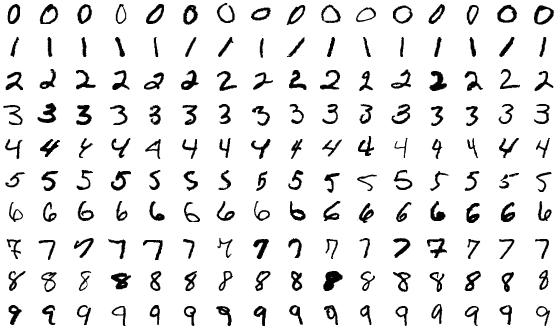

In [39]:
%pip install torch torchvision


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [41]:
import ssl

print(ssl.get_default_verify_paths())

DefaultVerifyPaths(cafile='/Library/Frameworks/Python.framework/Versions/3.11/etc/openssl/cert.pem', capath=None, openssl_cafile_env='SSL_CERT_FILE', openssl_cafile='/Library/Frameworks/Python.framework/Versions/3.11/etc/openssl/cert.pem', openssl_capath_env='SSL_CERT_DIR', openssl_capath='/Library/Frameworks/Python.framework/Versions/3.11/etc/openssl/certs')


In [42]:
from torchvision import datasets

# MNIST load
mnist_train = datasets.MNIST(root='./data', train=True, download=True)
mnist_test  = datasets.MNIST(root='./data', train=False, download=True)


# flatten(28*28), normalization(0~1)
x_train = mnist_train.data.view(-1, 28 * 28).numpy().astype('float32') / 255.0
t_train = mnist_train.targets.numpy()
x_test  = mnist_test.data.view(-1, 28 * 28).numpy().astype('float32') / 255.0
t_test  = mnist_test.targets.numpy()

# one-hot encoding
n = len(np.unique(t_train))  # 보통 10
t_train = np.eye(n)[t_train]
t_test  = np.eye(n)[t_test]

print(f'x_train.shape: {x_train.shape}')  # (60000, 784)
print(f't_train.shape: {t_train.shape}')  # (60000, 10)
print(f'x_test.shape:  {x_test.shape}')   # (10000, 784)
print(f't_test.shape:  {t_test.shape}')   # (10000, 10)

100.0%
100.0%
100.0%
100.0%


x_train.shape: (60000, 784)
t_train.shape: (60000, 10)
x_test.shape:  (10000, 784)
t_test.shape:  (10000, 10)


https://docs.pytorch.org/vision/stable/datasets.html

MNIST말고도 다양한 데이터셋이 있습니다 :)

## 실험 과제

1. `batch_size`, `learning_rate`, `hidden_size`, `iters_num` 중 하나 이상을 바꿔보세요.
2. SGD, Momentum, AdaGrad의 train loss 그래프를 비교하세요.
3. 마지막 셀에 각 optimizer의 특징과 그래프에서 관찰한 차이를 작성하세요.


In [49]:
# 기본 설정은 optimizer마다 2 epoch씩 학습합니다.
iters_num = 1200
train_size = x_train.shape[0]
batch_size = 100
learning_rate = 1e-1

optimizer_classes = {
    "sgd": SGD,
    "momentum": Momentum,
    "adagrad": AdaGrad,
}
train_loss_list = {name: [] for name in optimizer_classes}
iter_per_epoch = max(train_size // batch_size, 1)


for name, optimizer_class in optimizer_classes.items():
    print(f"\n====== Training with {name.upper()} optimizer ======")

    # 같은 초기 가중치와 같은 mini-batch 순서를 사용해 공정하게 비교합니다.
    np.random.seed(SEED)
    current_network = TwoLayerNet(
        input_size=28 * 28,
        hidden_size=50,
        output_size=10,
    )

    if name == "momentum":
        current_optimizer = optimizer_class(
            lr=learning_rate,
            momentum=0.9,
        )
    else:
        current_optimizer = optimizer_class(lr=learning_rate)

    for iteration in range(iters_num):
        batch_mask = np.random.choice(train_size, batch_size)
        x_batch = x_train[batch_mask]
        t_batch = t_train[batch_mask]

        gradients = current_network.gradient(x_batch, t_batch)
        current_optimizer.update(current_network.params, gradients)

        loss = current_network.loss(x_batch, t_batch)
        train_loss_list[name].append(loss)

        if (iteration + 1) % iter_per_epoch == 0:
            epoch = (iteration + 1) // iter_per_epoch
            train_acc = current_network.accuracy(x_train, t_train)
            test_acc = current_network.accuracy(x_test, t_test)
            print(
                "Epoch {:d}, train: {:.4f}, test: {:.4f}".format(
                    epoch,
                    train_acc,
                    test_acc,
                )
            )



====== Training with SGD optimizer ======
Epoch 1, train: 0.9038, test: 0.9075
Epoch 2, train: 0.9253, test: 0.9261

====== Training with MOMENTUM optimizer ======
Epoch 1, train: 0.9554, test: 0.9518
Epoch 2, train: 0.9650, test: 0.9593

====== Training with ADAGRAD optimizer ======
Epoch 1, train: 0.9449, test: 0.9428
Epoch 2, train: 0.9539, test: 0.9485


In [47]:
%pip install matplotlib

  Obtaining dependency information for matplotlib from https://files.pythonhosted.org/packages/35/74/82bbdf683a301f4478384c8aaba6903631a2ca18294b2d7655c9a542bffb/matplotlib-3.11.1-cp311-cp311-macosx_11_0_arm64.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 2.7 MB/s eta 0:00:00
  Obtaining dependency information for contourpy>=1.0.1 from https://files.pythonhosted.org/packages/0d/44/c4b0b6095fef4dc9c420e041799591e3b63e9619e3044f7f4f6c21c0ab24/contourpy-1.3.3-cp311-cp311-macosx_11_0_arm64.whl.metadata
  Obtaining dependency information for cycler>=0.10 from https://files.pythonhosted.org/packages/e7/05/c19819d5e3d95294a6f5947fb9b9629efb316b96de511b418c53d245aae6/cycler-0.12.1-py3-none-any.whl.metadata
  Obtaining dependency information for fonttools>=4.28.2 from https://files.pythonhosted.org/packages/75/2b/a7f1545bdf5da69c4bda0cea2a5781f0ad2a6623e0277267672db43c5fe6/fonttools-4.63.0-cp311-cp311-macosx_10_9_universal2.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━

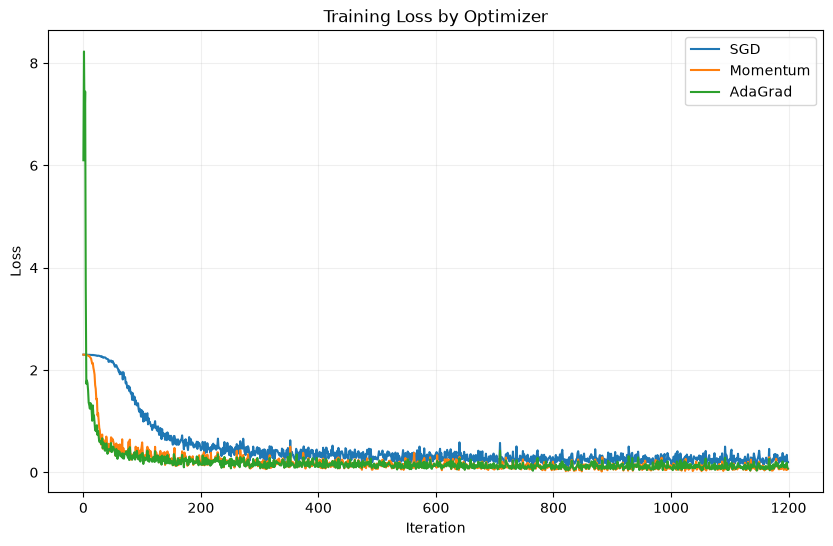

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(train_loss_list["sgd"], label="SGD", linewidth=1.5)
plt.plot(train_loss_list["momentum"], label="Momentum", linewidth=1.5)
plt.plot(train_loss_list["adagrad"], label="AdaGrad", linewidth=1.5)

plt.title("Training Loss by Optimizer")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(alpha=0.2)
plt.legend()
plt.show()


### 문제: 각 optimizer의 특징을 비교해주세요!
- SGD: SGD는 현재 gradient만을 이용해 파라미터를 업데이트한다. 구조가 단순하지만 learning rate가 작으면 학습 속도가 매우 느릴 수 있다. 기본 설정에서는 loss 감소가 느리고 정확도도 낮았지만, learning rate를 0.1로 높이자 성능이 크게 향상되었다. 따라서 이번 실험에서는 SGD가 learning rate의 영향을 가장 크게 받은 optimizer라고 볼 수 있다.

- momentum: Momentum은 현재 gradient뿐 아니라 이전 업데이트 방향을 함께 사용한다. 이 때문에 같은 방향의 학습이 이어질 때 속도가 붙고, 불필요한 진동은 줄어든다. 두 설정 모두 SGD보다 빠르게 loss가 감소했으며, learning rate를 높인 설정에서는 가장 높은 test accuracy인 0.9593을 기록했다. 이번 실험에서는 수렴 속도와 최종 성능이 가장 우수했다.

- adagrad: AdaGrad는 각 파라미터의 gradient 제곱을 누적하여 learning rate를 자동으로 조절한다. 기본 설정에서는 초반 loss를 가장 빠르게 줄였지만, learning rate를 0.1로 높였을 때 초기 loss가 크게 튀는 불안정한 모습이 나타났다. 이후에는 빠르게 안정화되었지만, 최종 test accuracy는 Momentum보다 낮았다. 

<기본 설정>

iters_num = 1200
train_size = x_train.shape[0]
batch_size = 100
learning_rate = 1e-2

====== Training with SGD optimizer ======
Epoch 1, train: 0.5066, test: 0.5084
Epoch 2, train: 0.7811, test: 0.7855

====== Training with MOMENTUM optimizer ======
Epoch 1, train: 0.9022, test: 0.9044
Epoch 2, train: 0.9217, test: 0.9231

====== Training with ADAGRAD optimizer ======
Epoch 1, train: 0.9111, test: 0.9136
Epoch 2, train: 0.9214, test: 0.9226

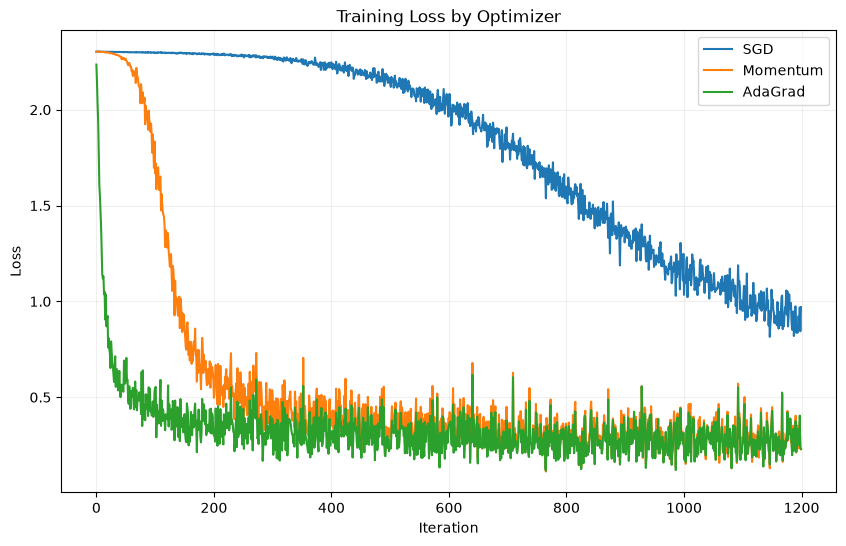


<바꾼 설정>

learning rate를 크게 했을 때 optimizer별 차이 비교


iters_num = 1200

train_size = x_train.shape[0]

batch_size = 100

learning_rate = 1e-1   # 0.01 → 0.1


====== Training with SGD optimizer ======

Epoch 1, train: 0.9038, test: 0.9075

Epoch 2, train: 0.9253, test: 0.9261



====== Training with MOMENTUM optimizer ======

Epoch 1, train: 0.9554, test: 0.9518

Epoch 2, train: 0.9650, test: 0.9593



====== Training with ADAGRAD optimizer ======

Epoch 1, train: 0.9449, test: 0.9428

Epoch 2, train: 0.9539, test: 0.9485
